In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df=pd.read_csv("/content/drive/MyDrive/Landslide project/Data from Actual Location.csv")
df

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,iso_risk,lstm_score,lstm_risk,confidence
0,27:51.2,107,29.600000,0.0,27.799999,89.599998,5.685560,8.866643,99.754570,0.122309,0,0.123682,0,0.773980
1,28:36.2,107,29.600000,0.0,27.650000,89.200001,12.548463,8.866643,99.754570,0.106923,0,0.134803,0,0.603367
2,30:06.3,107,29.600000,0.0,27.299999,89.400002,6.757516,8.866643,99.754570,0.115369,0,0.154084,0,0.623426
3,30:51.4,107,29.600000,0.0,27.100000,89.900002,6.764635,8.866643,99.754570,0.115590,0,0.154084,0,0.622325
4,31:36.4,107,29.650001,0.0,27.000000,90.450001,11.201781,8.866643,99.754570,0.098033,0,0.163325,0,0.613784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9612,07:02.3,108,41.799999,0.0,27.700001,84.099998,0.521180,8.866822,99.754433,0.129904,0,0.180721,0,0.999999
9613,07:36.1,109,26.700001,0.0,31.900000,64.900002,3.738859,8.868581,99.749565,0.110846,0,0.010416,0,0.999999
9614,07:42.3,107,31.800000,0.0,26.450000,88.200001,15.733137,8.866652,99.754547,0.071638,0,0.623885,0,0.956535
9615,07:42.7,106,36.500000,0.0,35.599998,54.900002,0.253338,8.886646,99.784538,0.049345,0,0.059769,0,0.999999


In [34]:
df.describe()

,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,iso_risk,lstm_score,lstm_risk,confidence
count,9617.000000,9617.000000,9617.000000,9617.000000,9617.000000,9617.000000,9617.000000,9617.000000,9617.000000,9617.000000,9617.000000,9617.000000,9617.000000
mean,107.620776,33.559647,0.004867,26.514259,87.890535,7.572798,8.731445,97.939840,0.058208,0.025996,0.311671,0.004471,0.960408
std,1.104275,6.997327,0.166770,3.800347,11.212345,9.445379,1.120672,19.047145,0.047601,0.163004,0.445850,0.066721,0.045872
min,105.000000,0.000000,-1.000000,0.000000,0.000000,-37.267765,-1.000000,-1.000000,-0.131156,0.000000,0.000499,0.000000,0.524283
25%,107.000000,26.600000,0.000000,23.700001,80.800003,0.431872,8.866679,99.749573,0.029231,0.000000,0.067619,0.000000,0.947577
50%,108.000000,32.900002,0.000000,24.400000,92.500000,2.139099,8.866838,99.754448,0.052548,0.000000,0.216258,0.000000,0.968333
75%,109.000000,41.650000,0.000000,29.799999,96.850002,13.461415,8.868607,99.754547,0.095367,0.000000,0.451894,0.000000,0.999999
max,109.000000,42.599998,5.588000,36.900002,100.000000,147.066278,8.886740,994.950012,0.175779,2.000000,7.288672,1.000000,0.999999


In [43]:
df

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,iso_risk,lstm_score,lstm_risk,confidence,datetime_full


#Convert time

In [35]:
df['datetime_full'] = pd.to_datetime(df['timestamp'], format='%H:%M:%S.%f', errors='coerce')
df['datetime_full'] = '2025-11-01 ' + df['datetime_full'].dt.strftime('%H:%M:%S.%f')
df['datetime_full'] = pd.to_datetime(df['datetime_full'])
df = df.dropna(subset=['datetime_full'])
display(df.head())

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,iso_risk,lstm_score,lstm_risk,confidence,datetime_full


In [36]:
df

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,iso_risk,lstm_score,lstm_risk,confidence,datetime_full


In [37]:
print("Sample values from the original 'timestamp' column:")
print(df['timestamp'].head())
print("\nData type of the 'timestamp' column:")
print(df['timestamp'].dtype)

Sample values from the original 'timestamp' column:
Series([], Name: timestamp, dtype: object)

Data type of the 'timestamp' column:
object


In [38]:
df_filtered = df[df['devID'] != 105]
display(df_filtered.head())

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,iso_risk,lstm_score,lstm_risk,confidence,datetime_full


/tmp/ipython-input-639558202.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df_filtered, x='timestamp', y='soil', hue='devID', palette=['red', 'green', 'blue', 'black', 'orange'])


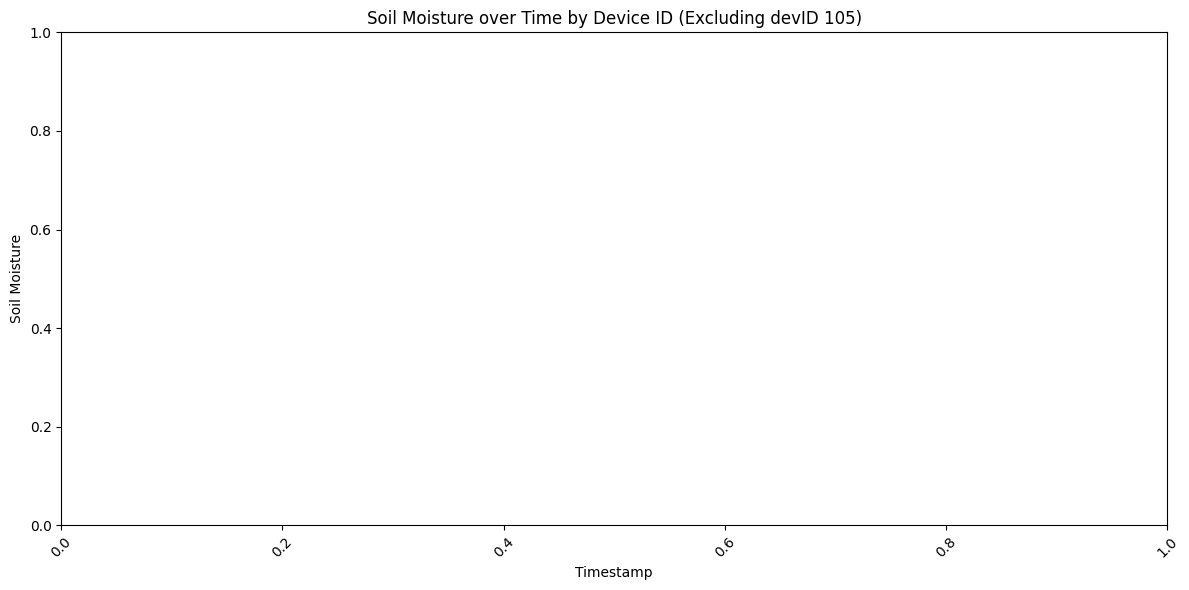

In [39]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtered, x='timestamp', y='soil', hue='devID', palette=['red', 'green', 'blue', 'black', 'orange'])
plt.title('Soil Moisture over Time by Device ID (Excluding devID 105)')
plt.xlabel('Timestamp')
plt.ylabel('Soil Moisture')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      0 non-null      object        
 1   devID          0 non-null      int64         
 2   soil           0 non-null      float64       
 3   rain           0 non-null      float64       
 4   temp           0 non-null      float64       
 5   humi           0 non-null      float64       
 6   geo            0 non-null      float64       
 7   lat            0 non-null      float64       
 8   lng            0 non-null      float64       
 9   iso_score      0 non-null      float64       
 10  iso_risk       0 non-null      int64         
 11  lstm_score     0 non-null      float64       
 12  lstm_risk      0 non-null      int64         
 13  confidence     0 non-null      float64       
 14  datetime_full  0 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(10), int64

In [41]:
df_106 = df[df['devID'] == 106]
df_107 = df[df['devID'] == 107]
df_108 = df[df['devID'] == 108]
df_109 = df[df['devID'] == 109]
df_106.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      0 non-null      object        
 1   devID          0 non-null      int64         
 2   soil           0 non-null      float64       
 3   rain           0 non-null      float64       
 4   temp           0 non-null      float64       
 5   humi           0 non-null      float64       
 6   geo            0 non-null      float64       
 7   lat            0 non-null      float64       
 8   lng            0 non-null      float64       
 9   iso_score      0 non-null      float64       
 10  iso_risk       0 non-null      int64         
 11  lstm_score     0 non-null      float64       
 12  lstm_risk      0 non-null      int64         
 13  confidence     0 non-null      float64       
 14  datetime_full  0 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(10), int64

In [42]:
print(filtered.head())
print(filtered["devID"].value_counts())

NameError: name 'filtered' is not defined

In [ ]:
filtered["devID"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("devID")
plt.ylabel("Count")
plt.title("Record count by devID (106-109)")
plt.show()